In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyprojroot import here
from IPython.display import display, Markdown, HTML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import shap
import lightgbm as lgb
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.svm import LinearSVC

In [2]:
ROOT = here()
FEATURES_PATH = ROOT / "data" / "esc50_features.csv"
FIGURES_DIR = ROOT / "outputs" / "figures"
REPORTS_DIR = ROOT / "outputs" / "reports"
MODELS_DIR = ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
features_df = pd.read_csv(FEATURES_PATH)
cols = features_df.columns.tolist()

In [4]:
FEATURE_COLS = [
    c for c in features_df.columns if c not in ["target", "category", "fold"]
]

In [5]:
X = features_df[FEATURE_COLS].values
y = features_df["target"].values
folds = features_df["fold"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
print(f"Liczba cech: {X.shape[1]}")
print(f"Liczba klas:  {len(np.unique(y))}")

Liczba cech: 182
Liczba klas:  50


In [ ]:
def cross_val_esc50(model, X, y, folds):
    scores = []
    rows = []

    is_lgb = isinstance(model, lgb.LGBMClassifier)
    if is_lgb:
        X = pd.DataFrame(X, columns=FEATURE_COLS)

    for test_fold in range(1, 6):
        train_idx = folds != test_fold
        test_idx = folds == test_fold

        X_train = X.iloc[train_idx] if is_lgb else X[train_idx]
        X_test = X.iloc[test_idx] if is_lgb else X[test_idx]

        model.fit(X_train, y[train_idx])
        acc = model.score(X_test, y[test_idx])
        scores.append(acc)
        rows.append((test_fold, acc))

    df = pd.DataFrame(rows, columns=["Fold", "Accuracy"])

    return scores, df

In [10]:
models = {
    "SVM": SVC(kernel="rbf", C=10, gamma="scale", probability=True),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=51114,
        n_jobs=-1,
    ),
}

In [ ]:
results = {}
all_rows = []

for name, model in models.items():
    scores, _df = cross_val_esc50(model, X_scaled, y, folds)
    results[name] = scores
    _df["Model"] = name
    all_rows.append(_df)

In [ ]:
pivot = pd.concat(all_rows, ignore_index=True).pivot(
    index="Fold", columns="Model", values="Accuracy"
)
mean_row = pivot.mean().rename("Średnia")
std_row = pivot.std().rename("Odchylenie standardowe")
summary = pd.concat([pivot, mean_row.to_frame().T, std_row.to_frame().T])

display(Markdown("### Wyniki kroswalidacji"))
display(summary)

### Wyniki kroswalidacji

Model,LightGBM,SVM
1,0.5625,0.612500
2,0.5750,0.560000
3,0.5975,0.605000
4,0.6275,0.652500
5,0.5550,0.585000
Średnia,0.5835,0.603000
Odchylenie standardowe,0.0294,0.034342


In [16]:
best_model = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
best_model.fit(X_scaled, y)
joblib.dump(best_model, MODELS_DIR / "svm_model.pkl")

['/mnt/studia/sygnaly_akustyczne_projekt_xai/models/svm_model.pkl']

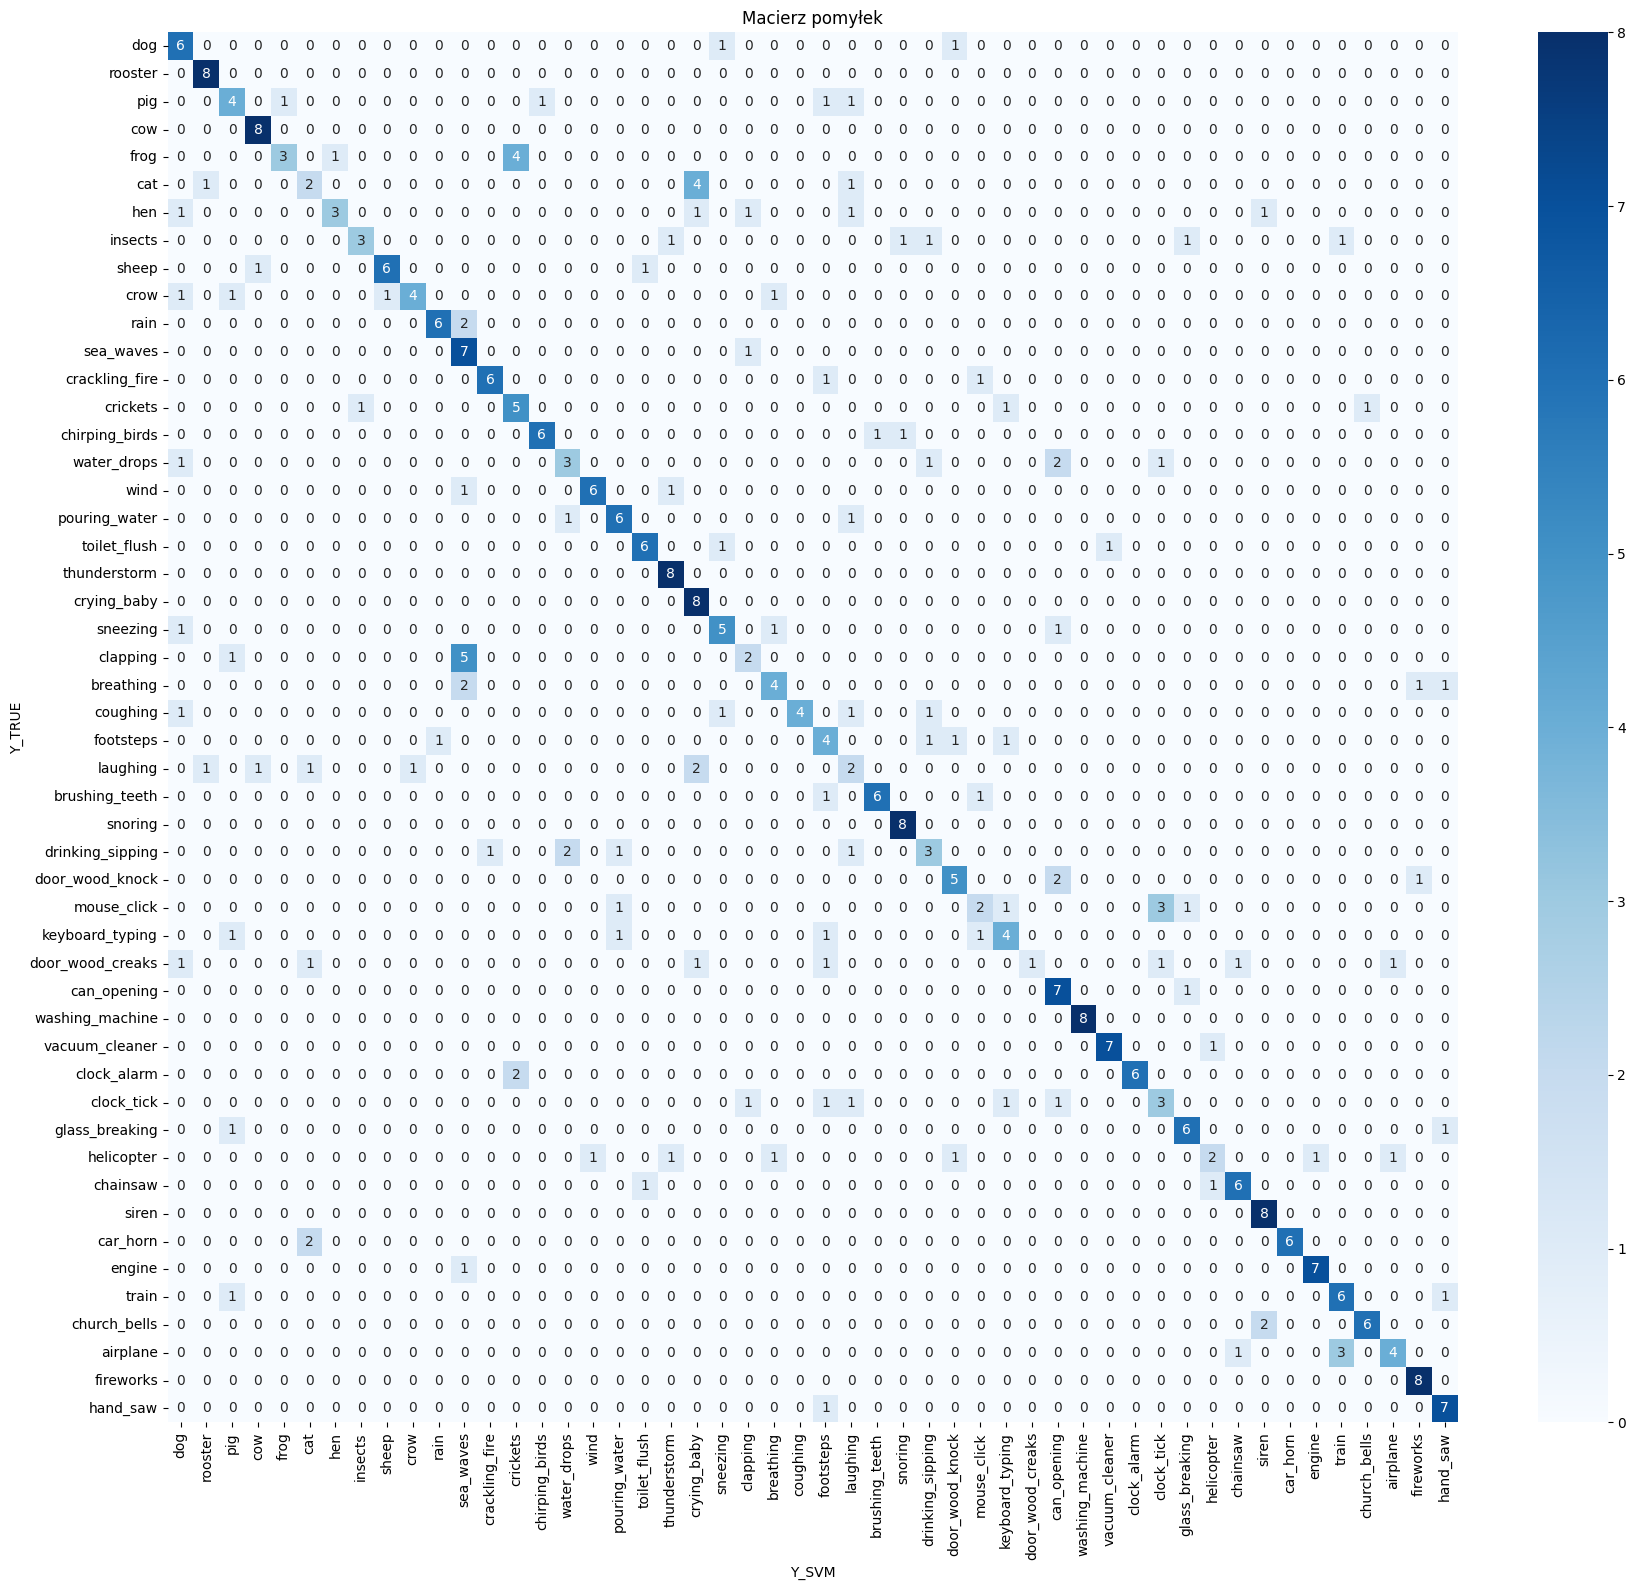

### Raport klasyfikacji

,precision,recall,f1-score,support
dog,0.50,0.75,0.60,8.00
rooster,0.80,1.00,0.89,8.00
pig,0.44,0.50,0.47,8.00
cow,0.80,1.00,0.89,8.00
frog,0.75,0.38,0.50,8.00
cat,0.33,0.25,0.29,8.00
hen,0.75,0.38,0.50,8.00
insects,0.75,0.38,0.50,8.00
sheep,0.86,0.75,0.80,8.00
crow,0.80,0.50,0.62,8.00


In [19]:
train_idx = folds != 4
test_idx = folds == 4

svm_eval = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
svm_eval.fit(X_scaled[train_idx], y[train_idx])
y_pred = svm_eval.predict(X_scaled[test_idx])

categories = features_df[features_df["fold"] == 4]["category"].values
label_names = [
    features_df[features_df["target"] == i]["category"].iloc[0] for i in range(50)
]

cm = confusion_matrix(y[test_idx], y_pred)
fig, ax = plt.subplots(figsize=(18, 16))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Blues",
    ax=ax,
)
ax.set_xlabel("Y_SVM")
ax.set_ylabel("Y_TRUE")
ax.set_title("Macierz pomyłek")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_svm.png")
plt.show()

display(Markdown("### Raport klasyfikacji"))
report_df = pd.DataFrame(
    classification_report(
        y[test_idx], y_pred, target_names=label_names, output_dict=True
    )
).T

report_df = report_df.round(2)
report_df.to_csv(REPORTS_DIR / "classification_report_svm_fold4.csv", index=True)
display(HTML(report_df.to_html()))

In [22]:
np.random.seed(51114)
bg_idx = np.random.choice(np.where(folds != 5)[0], size=100, replace=False)
X_background = X_scaled[bg_idx]

explain_idx = []
for _cls in range(50):
    cls_idx = np.where((folds == 5) & (y == _cls))[0]
    explain_idx.extend(cls_idx[:2])
X_explain = X_scaled[explain_idx]
y_explain = y[explain_idx]

In [24]:
explainer = shap.Explainer(svm_eval.predict_proba, X_background)

In [25]:
shap_values = explainer(X_explain)
print(shap_values.shape)

PermutationExplainer explainer: 101it [24:23, 14.63s/it]                         

(100, 182, 50)


In [26]:
shap_values.feature_names = FEATURE_COLS

In [ ]:
# shap.plots.bar(shap_values, max_display=20, show=False)

TypeError: only integer scalar arrays can be converted to a scalar index

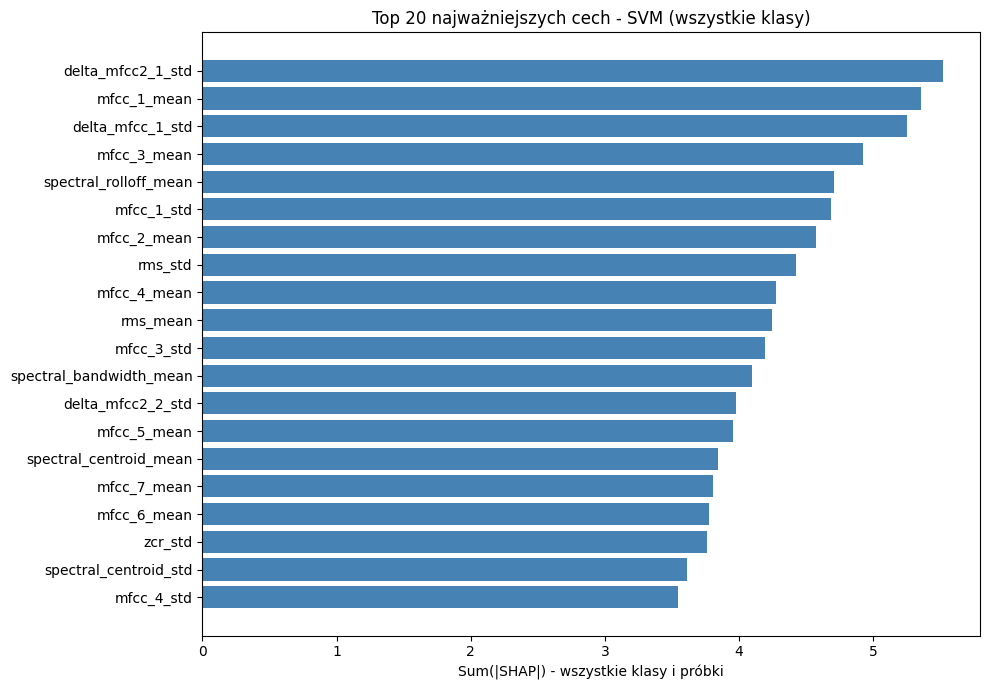

In [30]:
global_importance = np.abs(shap_values.values).sum(axis=(0, 2))

top_idx = np.argsort(global_importance)[::-1][:20]
top_idx_reversed = top_idx[::-1]

plt.figure(figsize=(10, 7))
plt.barh(
    [FEATURE_COLS[i] for i in top_idx_reversed],
    global_importance[top_idx_reversed],
    color="steelblue",
)
plt.xlabel("Sum(|SHAP|) - wszystkie klasy i próbki")
plt.title("Top 20 najważniejszych cech - SVM (wszystkie klasy)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_global_bar.png", dpi=150)
plt.show()

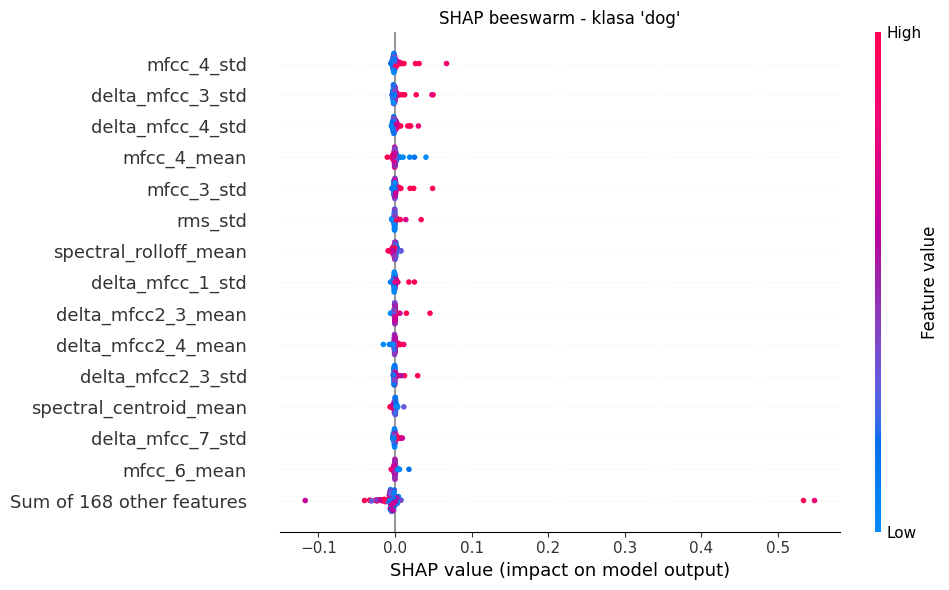

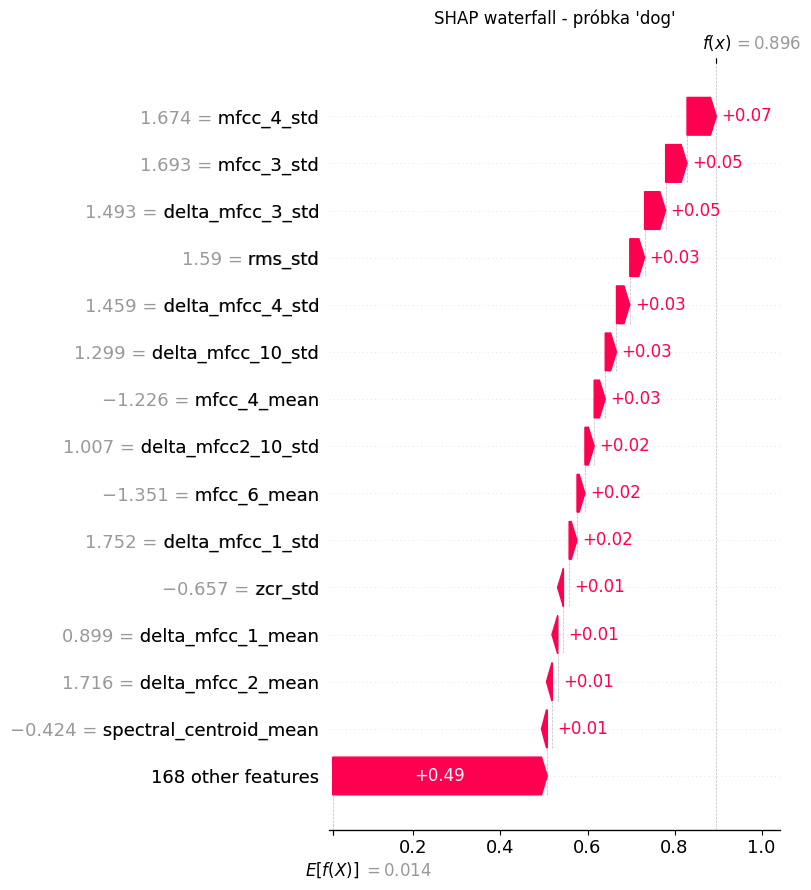

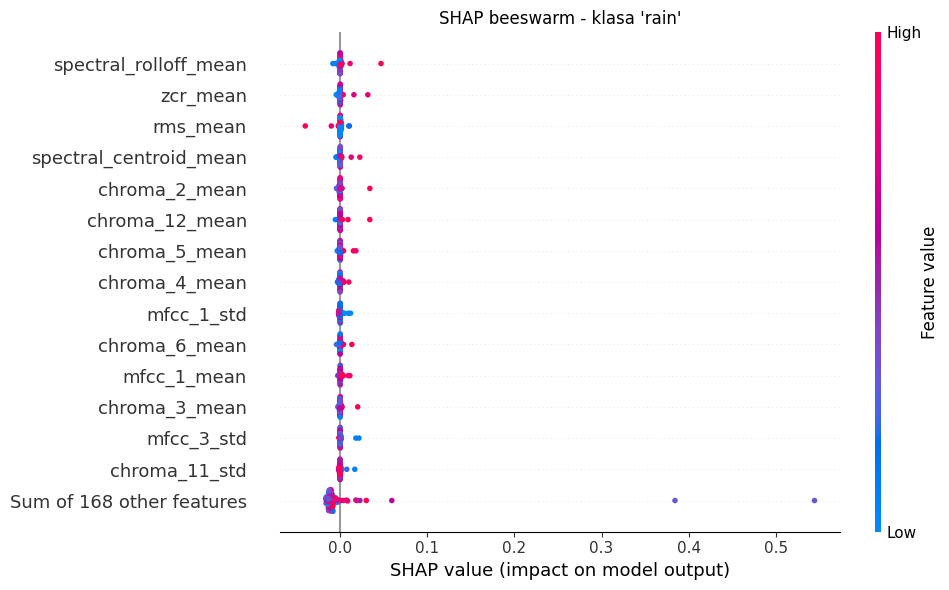

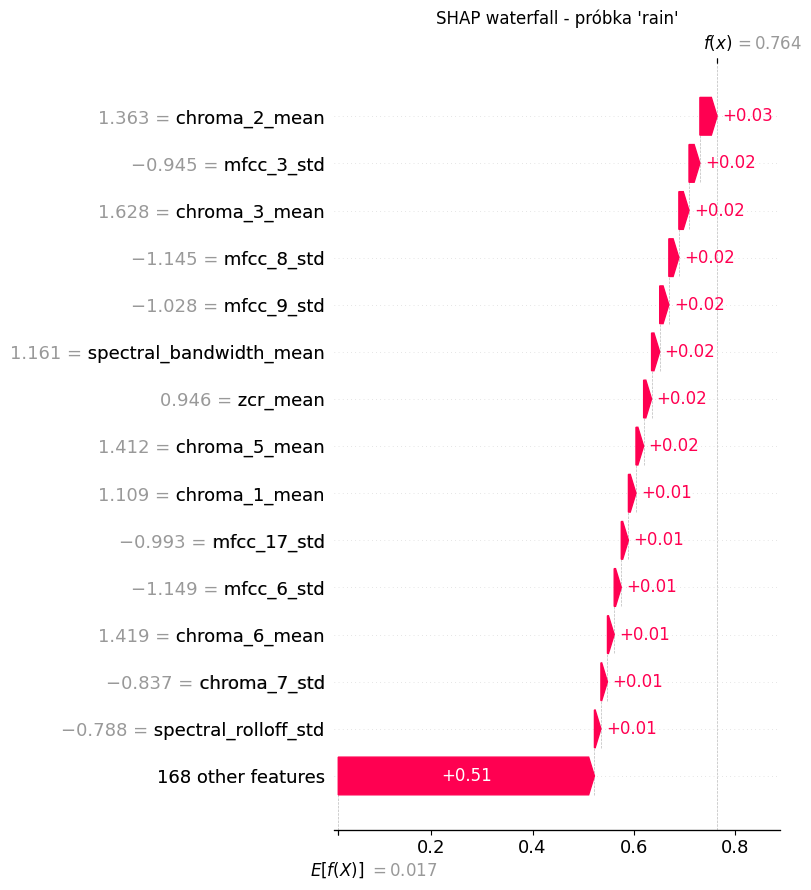

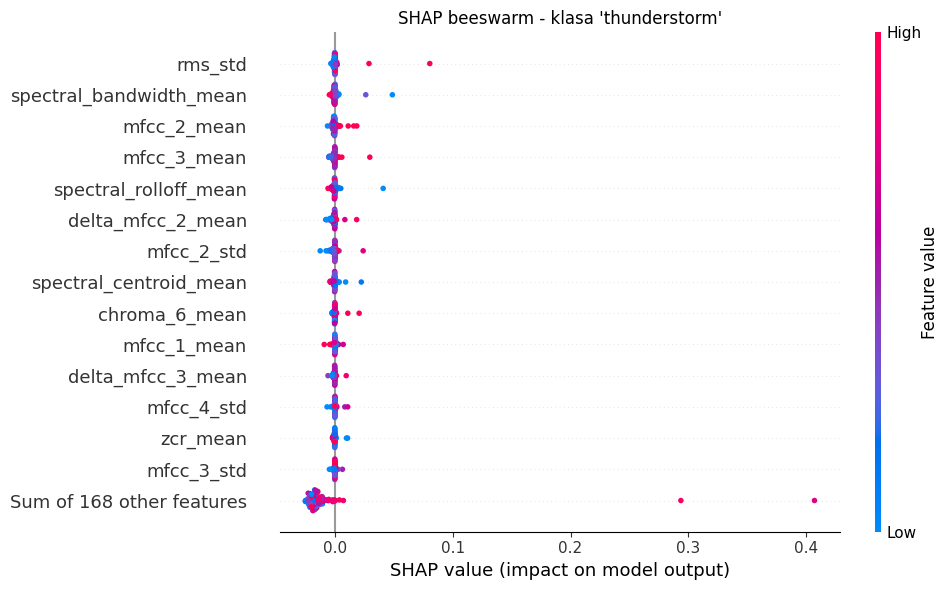

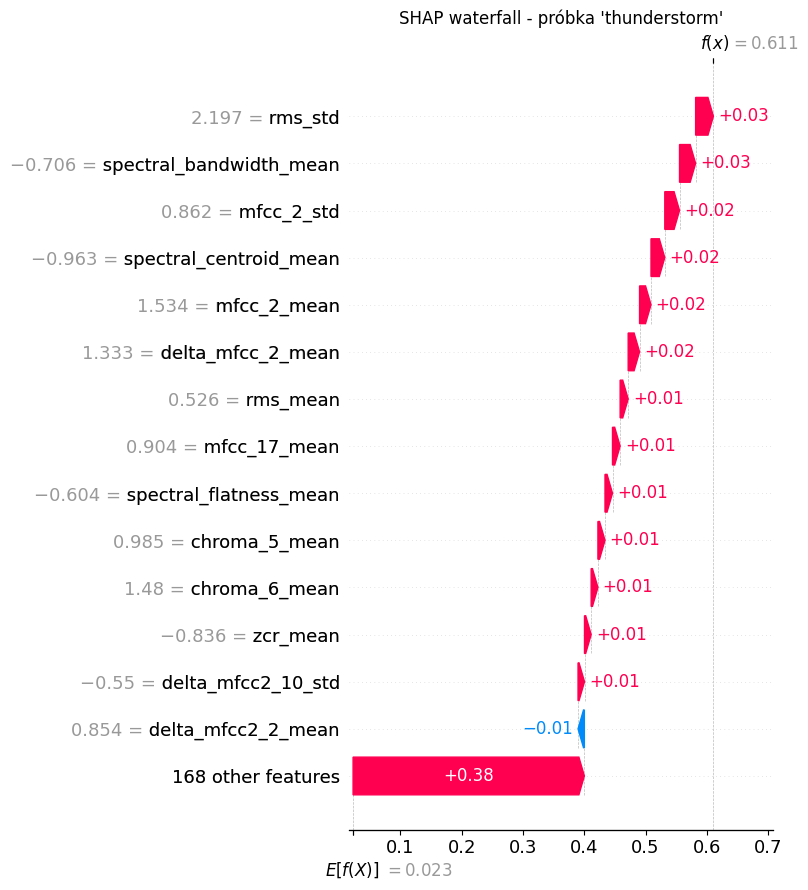

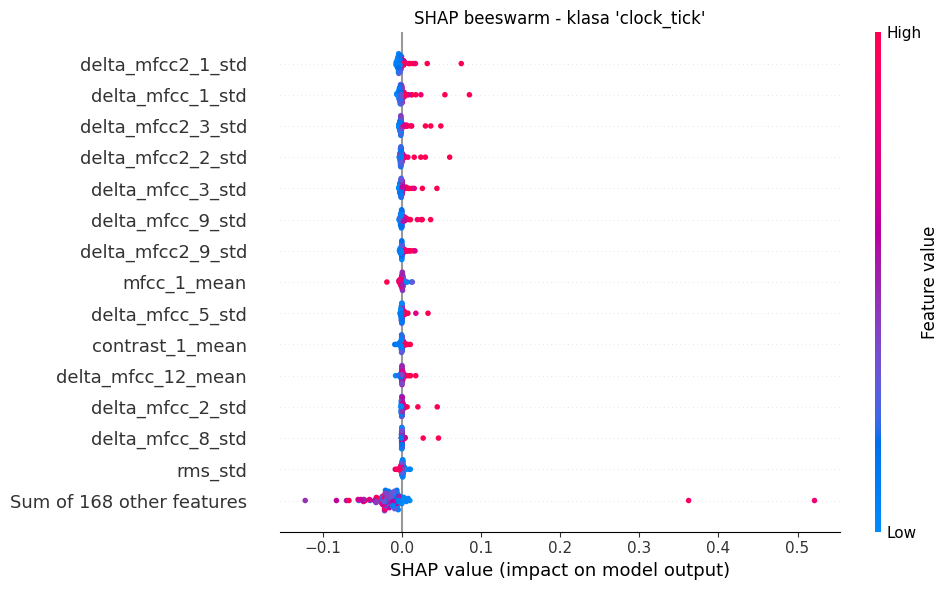

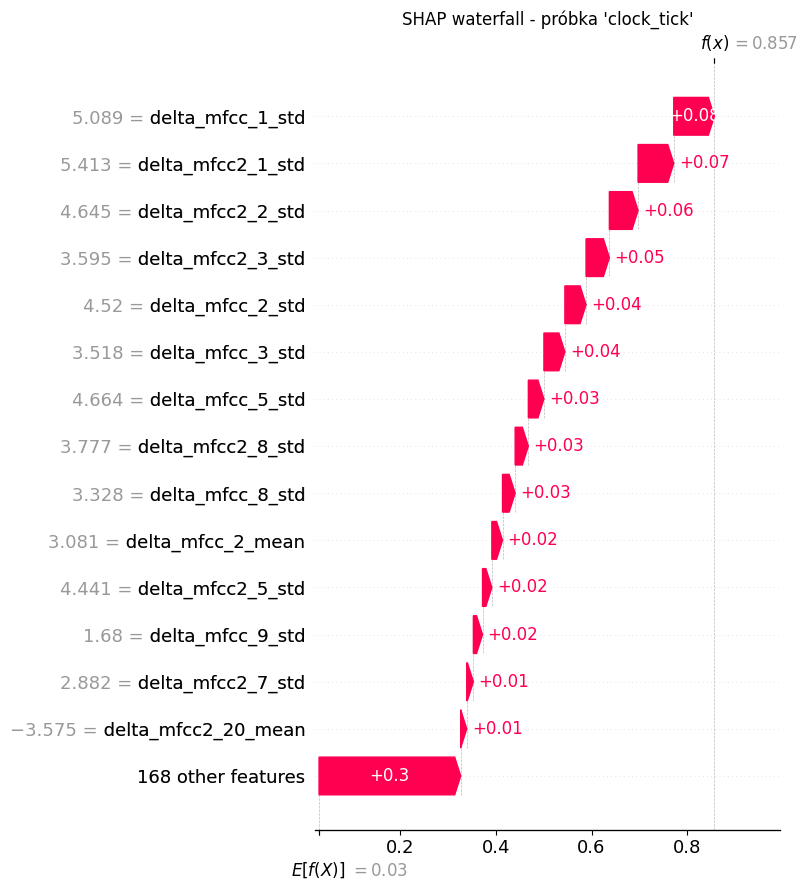

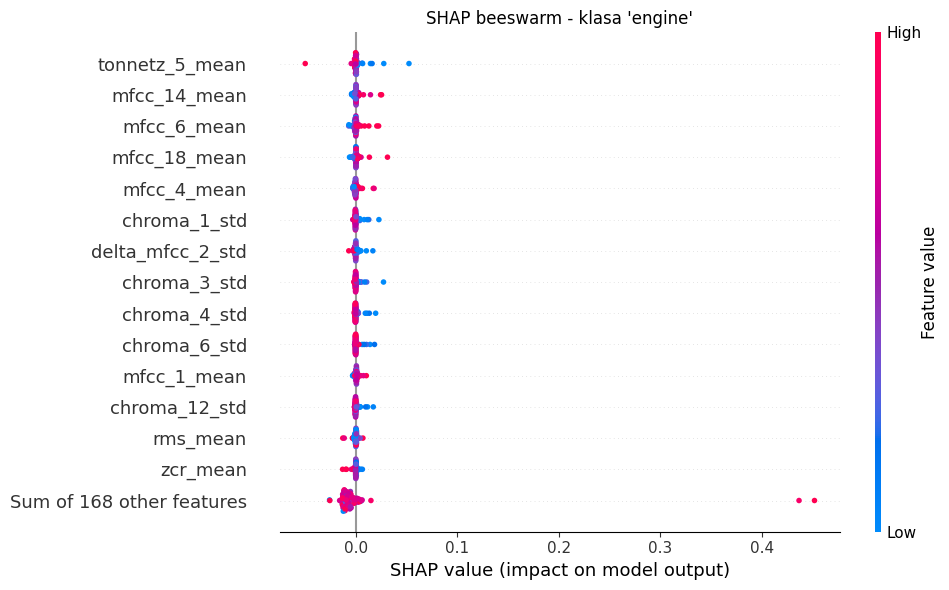

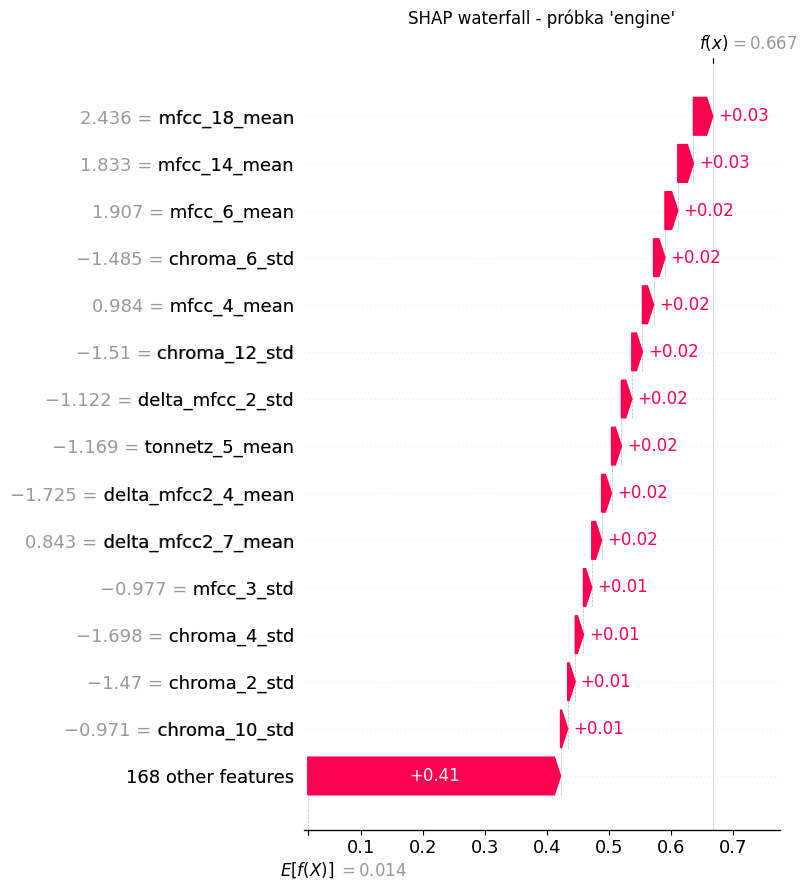

In [ ]:
for label, target_id in [
    ("dog", 0),
    ("rain", 10),
    ("thunderstorm", 19),
    ("clock_tick", 38),
    ("engine", 44),
]:
    sample_idx = np.where(y_explain == target_id)[0][0]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    shap.plots.beeswarm(
        shap_values[:, :, target_id], max_display=15, show=False, ax=ax1, plot_size=None
    )
    ax1.set_title(f"SHAP beeswarm - klasa '{label}'")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_beeswarm_{label}.png", dpi=150)
    plt.show()

    shap.plots.waterfall(
        shap_values[sample_idx, :, target_id], max_display=15, show=False
    )
    plt.title(f"SHAP waterfall - próbka '{label}'")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_waterfall_{label}.png", dpi=150)
    plt.show()

In [83]:
global_importance = np.abs(shap_values.values).sum(axis=(0, 2))
top_idx = np.argsort(global_importance)[::-1]

shap_results = {}

for n_features in [30, 40, 50, 60, 70, 80, 90, 100, 130]:
    selected = top_idx[:n_features]
    X_selected = X_scaled[:, selected]

    svm_sel = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
    scores, _ = cross_val_esc50(svm_sel, X_selected, y, folds)
    shap_results[n_features] = np.mean(scores)
    print(f"Top {n_features} cech: {np.mean(scores):.4f}")

shap_results[182] = np.mean(
    cross_val_esc50(
        SVC(kernel="rbf", C=10, gamma="scale", probability=True), X_scaled, y, folds
    )[0]
)
print(f"Wszystkie 182 cechy: {shap_results[182]:.4f}")

Top 30 cech: 0.5305
Top 40 cech: 0.6160
Top 50 cech: 0.6380
Top 60 cech: 0.6370
Top 70 cech: 0.6590
Top 80 cech: 0.6435
Top 90 cech: 0.6510
Top 100 cech: 0.6370
Top 130 cech: 0.6145
Wszystkie 182 cechy: 0.6030


/tmp/ipykernel_56965/2242765643.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


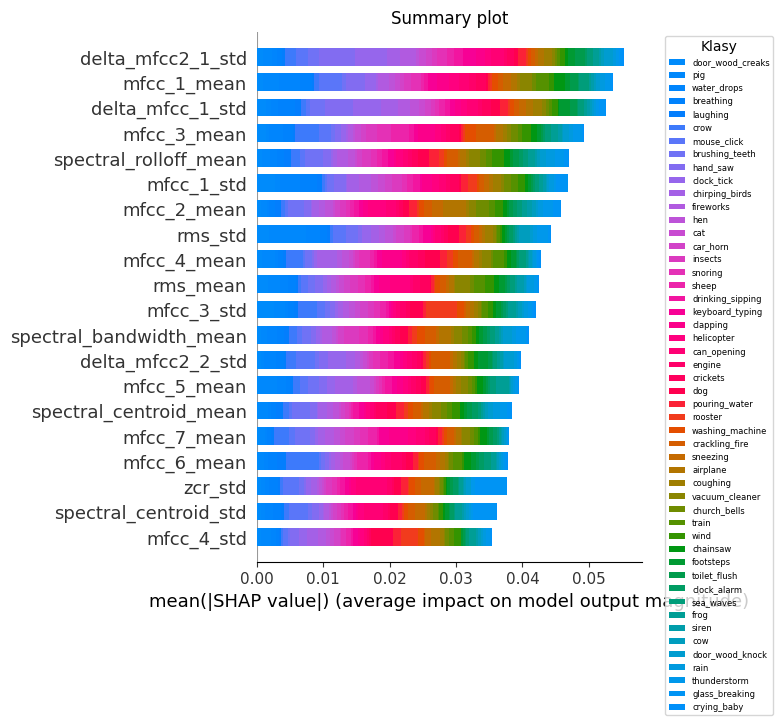

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
shap_values_list = [shap_values.values[:, :, i] for i in range(50)]

shap.summary_plot(
    shap_values_list,
    X_explain,
    feature_names=FEATURE_COLS,
    class_names=label_names,
    plot_type="bar",
    max_display=20,
    show=False,
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    labels,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=6,
    title="Klasy",
)

plt.title("Summary plot")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_lgb_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [75]:
K_ = [30, 40, 50, 60, 70, 80, 90, 100, 130]

In [ ]:
results_kbest = {}

for k in K_:
    selector = SelectKBest(mutual_info_classif, k=k)
    X_kbest = selector.fit_transform(X_scaled, y)

    svm_kbest = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
    scores, _ = cross_val_esc50(svm_kbest, X_kbest, y, folds)
    results_kbest[k] = np.mean(scores)
    print(f"Top {k} cech (MI): {np.mean(scores):.4f}")

results_kbest[182] = np.mean(
    cross_val_esc50(
        SVC(kernel="rbf", C=10, gamma="scale", probability=True), X_scaled, y, folds
    )[0]
)
print(f"Wszystkie 182 cechy:  {results_kbest[182]:.4f}")

Top 30 cech (MI): 0.5905
Top 40 cech (MI): 0.6090
Top 50 cech (MI): 0.6115
Top 60 cech (MI): 0.6125
Top 70 cech (MI): 0.6115
Top 80 cech (MI): 0.6260
Top 90 cech (MI): 0.6315
Top 100 cech (MI): 0.6215
Top 130 cech (MI): 0.6430
Wszystkie 182 cechy:  0.6030


In [ ]:
results_svm_selection = {}

for k in K_:
    selector = SelectFromModel(
        LinearSVC(C=0.01, max_iter=2000, random_state=42), max_features=k
    )
    X_selected = selector.fit_transform(X_scaled, y)

    svm_sel = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
    scores, _ = cross_val_esc50(svm_sel, X_selected, y, folds)
    results_svm_selection[k] = np.mean(scores)
    print(f"Top {k} cech (LinearSVC): {np.mean(scores):.4f}")

results_svm_selection[182] = shap_results[182]
print(f"Wszystkie 182 cechy: {results_svm_selection[182]:.4f}")

Top 30 cech (LinearSVC): 0.6030
Top 40 cech (LinearSVC): 0.6390
Top 50 cech (LinearSVC): 0.6640
Top 60 cech (LinearSVC): 0.6560
Top 70 cech (LinearSVC): 0.6560
Top 80 cech (LinearSVC): 0.6585
Top 90 cech (LinearSVC): 0.6585
Top 100 cech (LinearSVC): 0.6585
Top 130 cech (LinearSVC): 0.6585
Wszystkie 182 cechy: 0.6030


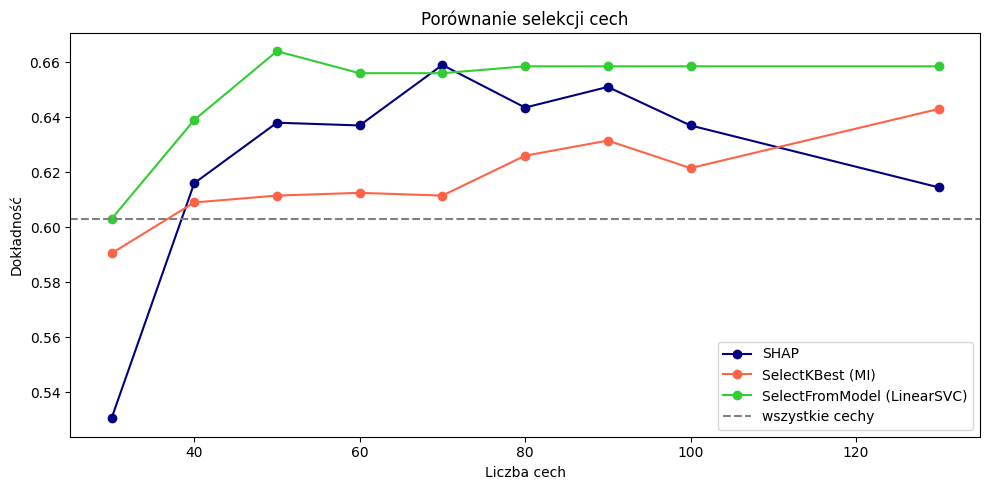

In [85]:
plt.figure(figsize=(10, 5))

plt.plot(K_, [shap_results[k] for k in K_], marker="o", color="navy", label="SHAP")
plt.plot(
    K_,
    [results_kbest[k] for k in K_],
    marker="o",
    color="tomato",
    label="SelectKBest (MI)",
)
plt.plot(
    K_,
    [results_svm_selection[k] for k in K_],
    marker="o",
    color="limegreen",
    label="SelectFromModel (LinearSVC)",
)
plt.axhline(0.6030, color="gray", linestyle="--", label="wszystkie cechy")

plt.xlabel("Liczba cech")
plt.ylabel("Dokładność")
plt.title("Porównanie selekcji cech")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_selection_comparison.png", dpi=150)
plt.show()